# QASMTrans Demo
This notebook mirrors the `python/demo.py` script but walks through the workflow step by step without helper functions.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from tempfile import NamedTemporaryFile

from IPython.display import Image, display
import qasmtrans as qt  # type: ignore
import qasmtrans.plot_pulses as plot_pulses  # type: ignore


def find_repo_root(start: Path) -> Path:
    base = start if start.is_dir() else start.parent
    for candidate in [base, *base.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Cannot locate project root containing pyproject.toml")


START_PATH = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
REPO = find_repo_root(START_PATH)
print(f"Project root: {REPO}")


Project root: /home/hoyt924.linux/qasmtrans


## 1. Transpile the benchmark circuit from file
Configure the transpiler to read `adder_n4.qasm` and target the IBMQ Toronto backend configuration shipped with the repo.


In [2]:
qasm_path = REPO / 'notebooks/single_qubit_demo.qasm'
backend_path = REPO / 'notebooks/rigetti_ankaa8q_device.json'

opts_file = qt.TranspileOptions()
opts_file.backend_config = str(backend_path)
opts_file.output_path = str(REPO / "data" / "output_demo")
opts_file.verbose = 1
opts_file.disable_mapomatic = False
opts_file.mapomatic_limit = 200

result_file = qt.transpile_qasm(str(qasm_path), opts_file)
print("Log:", result_file.log)
print("Output QASM path:", result_file.output_qasm_path)
print("Preview:")
for line in result_file.output_qasm.splitlines()[:8]:
    print("    " + line)


Log: Transpiled single_qubit_demo.qasm with mode=ibmq, qubits=8
STEP-1. Initial gate decomposition time: 0.003174ms
STEP-2. Routing and mapping time: 0.046875ms
Calibration-aware heuristic (critical path fidelity): best 1.000000, worst 1.000000
Log-fidelity spread: 0.000e+00
Critical path aggregation: log product
Mapomatic timing (ms): critical-path prep 0.000, embedding 0.011, scoring 0.002, apply 0.000
Critical path latency: 0.000000 s
Mapomatic evaluated 2 candidate mapping(s) (identity fallback).
Best and worst heuristic values match because all evaluated mappings scored identically.
STEP-3. Calibration-aware optimization time: 0.020996ms
STEP-4. Basis gate decomposition time: 0.004883ms
 total QASMTrans time: 0.054932ms
Transpiled circuit contains 8 qubits and 16 basis gates: rz:8, x:8, 

Output QASM path: /home/hoyt924.linux/qasmtrans/data/output_demo
Preview:
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[8];
    creg c[8];
    x q[4]; 
    rz(1.5708) q[4]; 
    x q[5]; 

## 2. Transpile directly from a raw QASM string
Read the same benchmark circuit into memory to highlight how string inputs can be passed directly without touching the filesystem.


In [3]:
qasm_text = qasm_path.read_text()

opts_string = qt.TranspileOptions()
opts_string.backend_config = str(backend_path)
opts_string.output_path = str(REPO / "data" / "output_demo_string")
opts_string.disable_mapomatic = True
opts_string.verbose = 0

result_string = qt.transpile_qasm(qasm_text, opts_string)
print("Log:", result_string.log)
print("QASM length:", len(result_string.output_qasm))


Log: Transpiled qasmtrans_input_3613_1764812872676990303.qasm with mode=ibmq, qubits=8
QASM length: 450


## 3. Build a minimal backend + pulse template and plot the resulting pulses
Create lightweight backend/pulse JSON payloads on the fly, transpile a two-qubit program, and emit a pulse plot.


Log: Transpiled qasmtrans_input_3613_1764812872682799386.qasm with mode=ibmq, qubits=8
Pulse JSON path: /home/hoyt924.linux/qasmtrans/data/output_demo_pulses_pulses.json


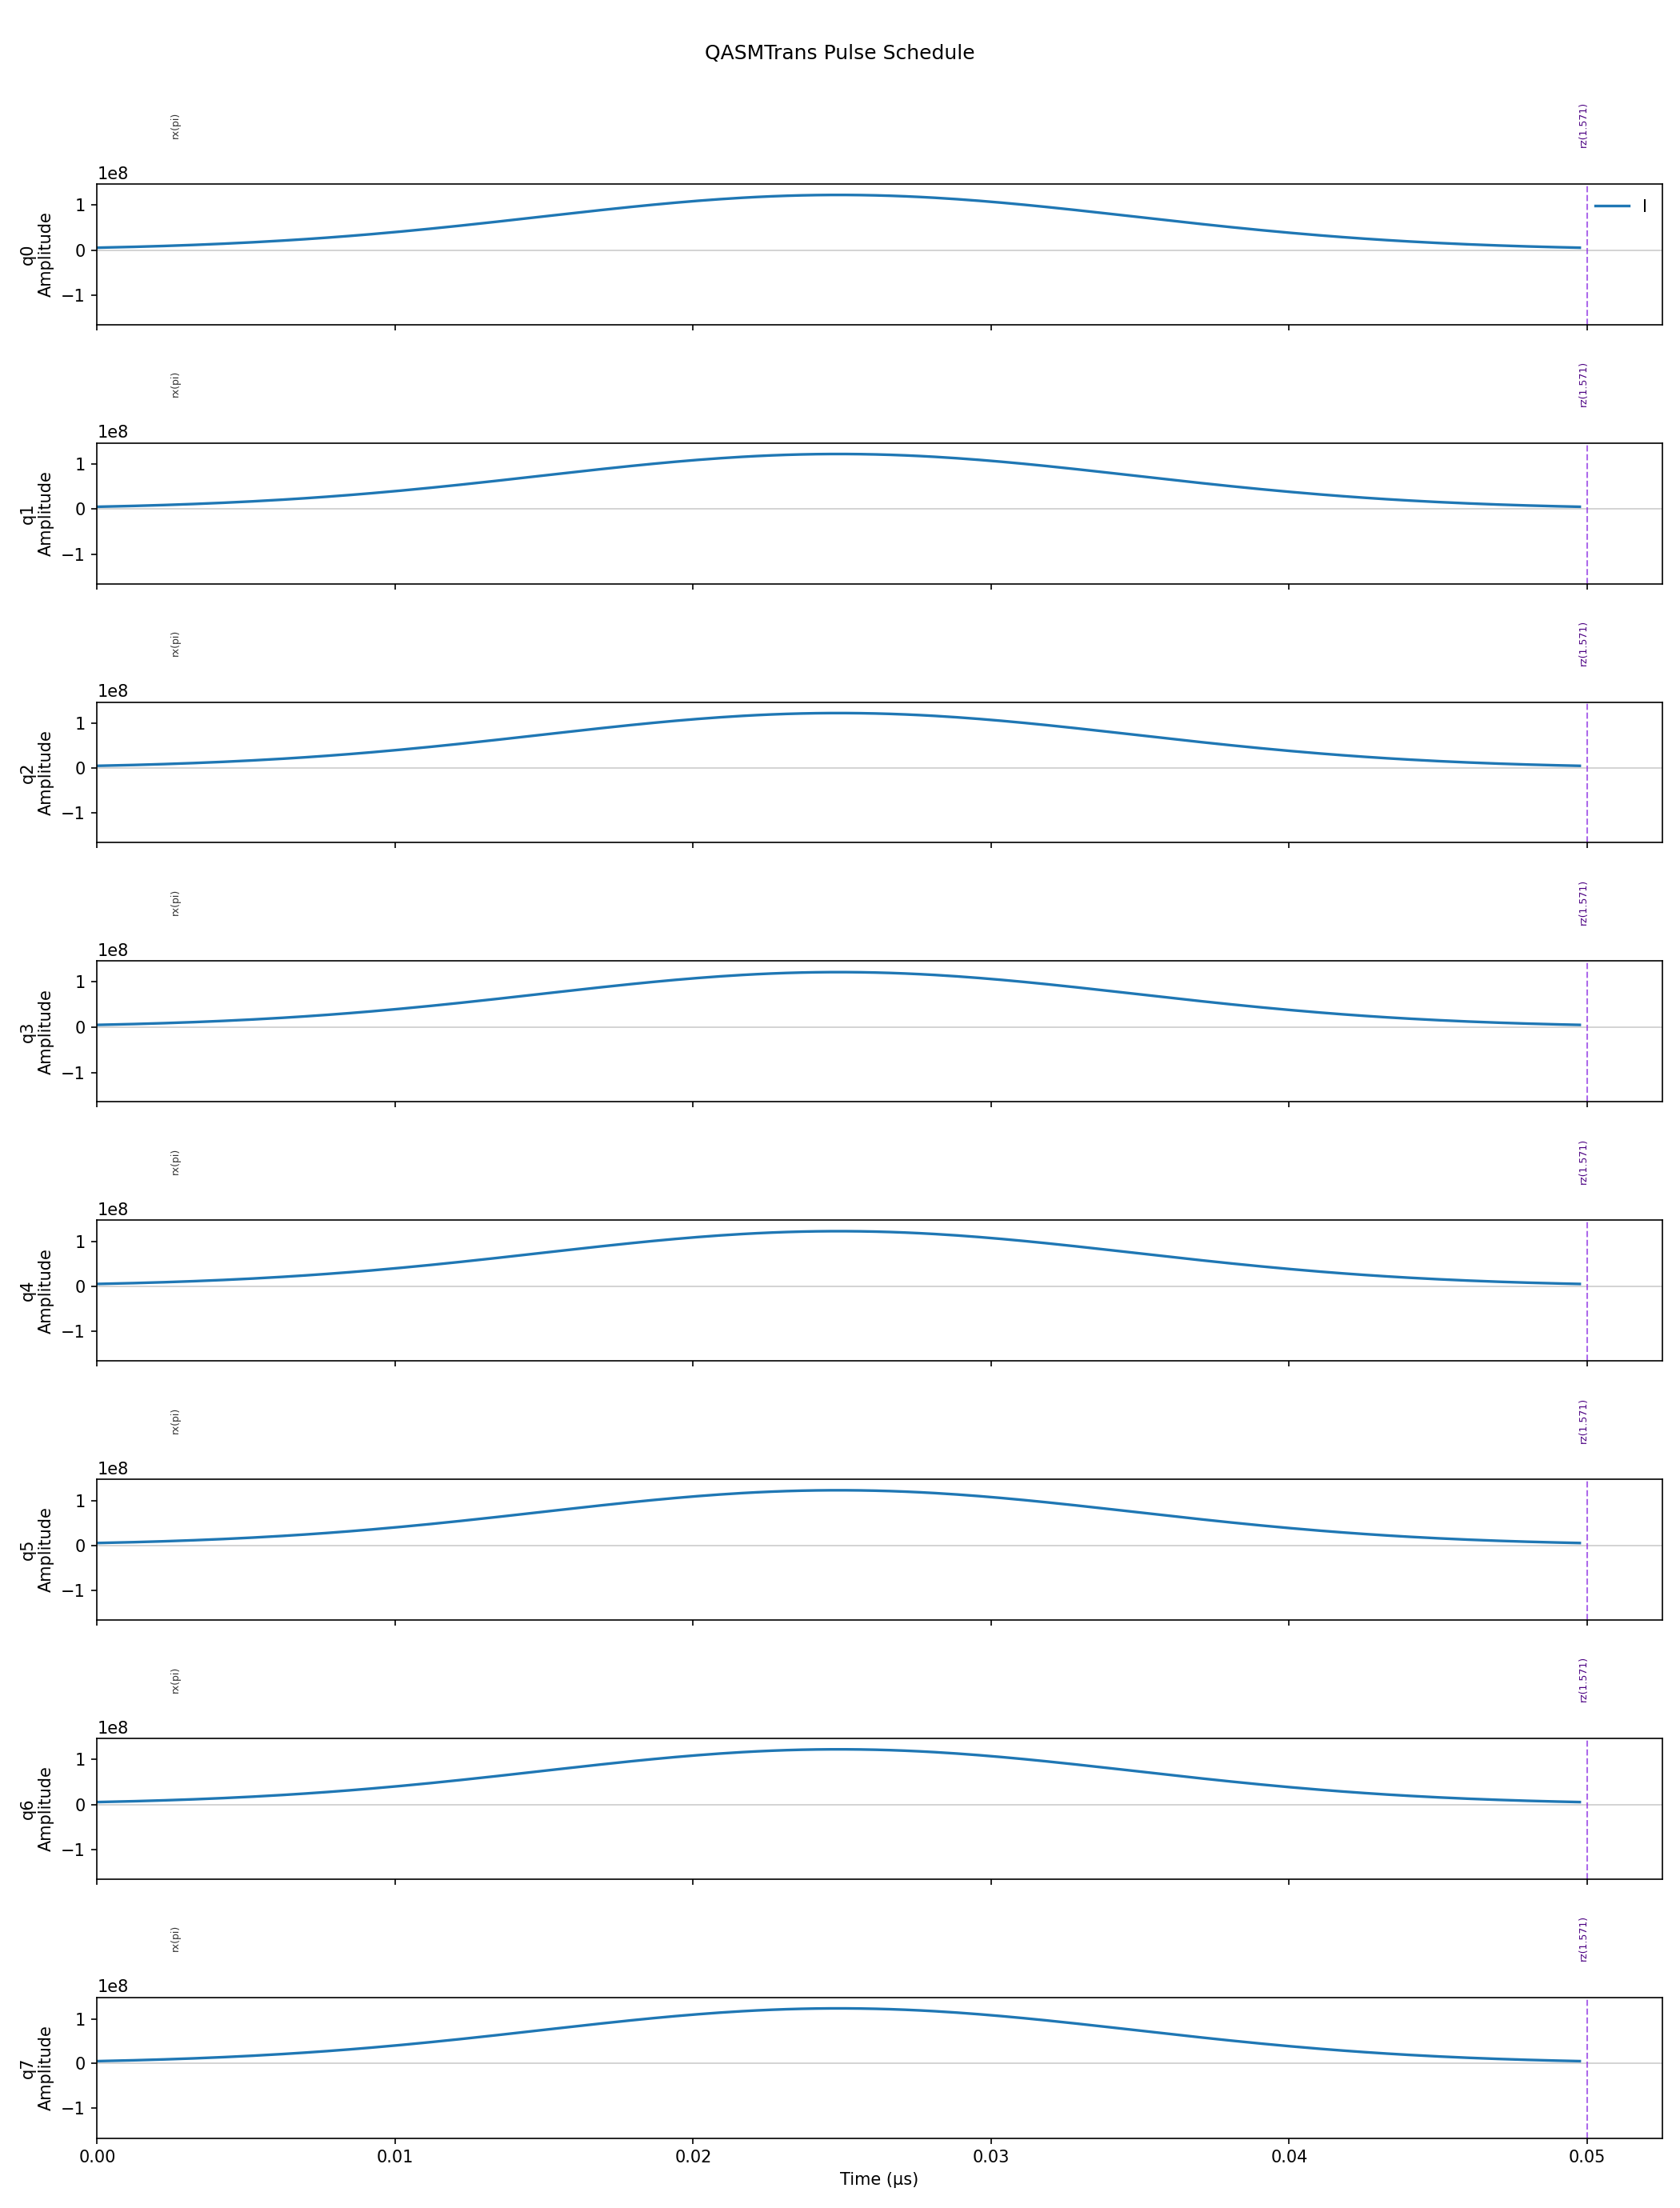

In [4]:
qasm_demo = (REPO / 'notebooks' / 'single_qubit_demo.qasm').read_text()
backend_path = REPO / 'notebooks' / 'rigetti_ankaa8q_device.json'
pulse_path = REPO / 'notebooks' / 'rigetti_ankaa8q_pulses.json'

opts = qt.TranspileOptions()
opts.backend_config = str(backend_path)
opts.pulse_template_path = str(pulse_path)
opts.output_path = str(REPO / "data" / "output_demo_pulses")
opts.limited_qubits = False

result_pulses = qt.transpile_qasm(qasm_demo, opts)
print("Log:", result_pulses.log)
print("Pulse JSON path:", result_pulses.pulse_path)

pulse_doc = result_pulses.pulse_doc if result_pulses.pulse_doc is not None else json.loads(result_pulses.pulse_schedule or "{}")
analog_events, virtual_events, labels = plot_pulses.build_qubit_events(pulse_doc)

from tempfile import NamedTemporaryFile
with NamedTemporaryFile("wb", suffix=".png", delete=False) as tmp_plot:
    plot_path = Path(tmp_plot.name)

plot_pulses.plot_events(
    analog_events_by_qubit=analog_events,
    virtual_events_by_qubit=virtual_events,
    label_sequences=labels,
    title="QASMTrans Pulse Schedule",
    output_path=plot_path,
    dpi=150,
    samples_per_us=200.0,
)
display(Image(filename=str(plot_path)))
plot_path.unlink(missing_ok=True)



## 4. Hardware sanity check: QICK loopback (hardware only)
Quickly verify the RF board can transmit and receive a simple pulse train before driving it with qasmtrans output. This follows the same loopback recipe from the reference notebook and is fully guarded so it skips cleanly off hardware.


In [5]:

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ENABLE_QICK = False  # set to True on hardware
BITSTREAM_PATH = Path('/home/xilinx/jupyter_notebooks/fw/2024-09-28_216_tprocv2r21_rfb_standard/qick_216_rfb.bit')
GEN_CH = 5  # DAC in QICK firmware numbering
RO_CH = 0   # ADC in QICK firmware numbering
ATTENUATOR_GEN = (5, 15)  # (dB, dB) on DAC chain
ATTENUATOR_RO = 30        # dB on ADC chain
IQ_SOFT_AVGS = 100

if not BITSTREAM_PATH.exists():
    print('Warning: bitstream path does not exist:', BITSTREAM_PATH)


In [6]:

HAS_QICK = False
try:
    from qick import *
    from qick.rfboard import *
    from qick.asm_v2 import AveragerProgramV2, QickSweep1D
    HAS_QICK = True
    print('QICK imports OK.')
except Exception as exc:
    print('Skipping hardware section: QICK not available in this environment.', exc)


Skipping hardware section: QICK not available in this environment. No module named 'qick'


In [7]:

if not (ENABLE_QICK and HAS_QICK):
    print('Hardware sanity loopback disabled (set ENABLE_QICK=True on a QICK board).')
else:
    soc = RFQickSoc216V1(str(BITSTREAM_PATH), clk_output=None)
    soccfg = soc
    print(soccfg)

    class LoopbackProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            ro_ch = cfg['ro_ch']
            gen_ch = cfg['gen_ch']
            self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
            self.add_readoutconfig(ch=ro_ch, name='myro', freq=cfg['freq'], gen_ch=gen_ch, outsel='product')
            self.add_cosine(ch=gen_ch, name='ramp', length=cfg['ramp_len'], even_length=True)
            self.add_pulse(
                ch=gen_ch, name='mypulse', ro_ch=ro_ch, style='const', freq=cfg['freq'], length=cfg['flat_len'], phase=cfg['phase'], gain=cfg['gain']
            )
            self.send_readoutconfig(ch=cfg['ro_ch'], name='myro', t=0)

        def _body(self, cfg):
            self.delay_auto()
            self.pulse(ch=cfg['gen_ch'], name='mypulse', t=0.0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], mr=True)

    config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'mixer_freq': 3500,
        'freq': 4000,
        'nqz': 2,
        'trig_time': 0.0,
        'ro_len': 3.0,
        'flat_len': 2.0,
        'ramp_len': 1.0,
        'phase': 0,
        'gain': 1.0,
    }

    soc.rfb_set_gen_filter(config['gen_ch'], fc=config['freq']/1000, ftype='bandpass', bw=1.0)
    soc.rfb_set_ro_filter(config['ro_ch'], fc=config['freq']/1000, ftype='bandpass', bw=1.0)
    soc.rfb_set_gen_rf(config['gen_ch'], *ATTENUATOR_GEN)
    soc.rfb_set_ro_rf(config['ro_ch'], ATTENUATOR_RO)

    prog = LoopbackProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_list = prog.acquire_decimated(soc, soft_avgs=IQ_SOFT_AVGS)
    t = prog.get_time_axis(ro_index=0)
    iq = iq_list[0]

    plt.figure(figsize=(10, 4))
    plt.plot(t, iq[:, 0], label='I value')
    plt.plot(t, iq[:, 1], label='Q value')
    plt.legend()
    plt.ylabel('amplitude [ADU]')
    plt.xlabel('time [us]')
    plt.title('QICK loopback sanity check')
    plt.show()


Hardware sanity loopback disabled (set ENABLE_QICK=True on a QICK board).



## 5. Extract pulse events to feed hardware
Flatten the qasmtrans-generated pulse schedule into a simple list of pulse events (start time, width, amplitude) that we can hand to the QICK program.


In [8]:

from pprint import pprint

pulse_events = []
if 'analog_events' not in globals():
    print('analog_events not available; run Section 3 first to build pulse events.')
else:
    for qubit, events in analog_events.items():
        for ev in events:
            pulse_events.append({
                'start_us': float(ev.get('start_us', 0.0)),
                'width_us': float(ev.get('width_us', 0.0)),
                'amplitude': float(ev.get('amplitude', 0.0)),
                'qubit': qubit,
                'label': ev.get('label', ''),
            })
    pulse_events.sort(key=lambda e: e['start_us'])
    print(f'Prepared {len(pulse_events)} pulse events from qasmtrans output.')
    pprint(pulse_events[:3])


Prepared 8 pulse events from qasmtrans output.
[{'amplitude': 123437963.20072488,
  'label': 'rx\n(rx_q7_pi)',
  'qubit': '7',
  'start_us': 0.0,
  'width_us': 0.05},
 {'amplitude': 122198626.22079794,
  'label': 'rx\n(rx_q0_pi)',
  'qubit': '0',
  'start_us': 0.0,
  'width_us': 0.05},
 {'amplitude': 123190095.8047395,
  'label': 'rx\n(rx_q5_pi)',
  'qubit': '5',
  'start_us': 0.0,
  'width_us': 0.05}]



## 6. QICK loopback of qasmtrans pulse train (hardware only)
This section reuses the hardware settings above, loads the bitstream, and sends the qasmtrans-generated pulse train over DAC/ADC. It is wrapped in guards so the rest of the notebook still runs without hardware.


In [9]:

# Map qasmtrans pulses to QICK-friendly events

def build_qick_pulse_events(events, gain_scale=15000):
    qick_events = []
    for ev in events:
        gain = int(abs(ev.get('amplitude', 0.0)) * gain_scale)
        gain = max(0, min(gain, 0x7FFF))
        qick_events.append({
            'start_us': float(ev.get('start_us', 0.0)),
            'width_us': max(float(ev.get('width_us', 0.0)), 0.05),
            'gain': gain,
        })
    return qick_events


In [10]:

import matplotlib.pyplot as plt

if not (ENABLE_QICK and HAS_QICK):
    print('Hardware loopback disabled (set ENABLE_QICK=True on a QICK board).')
else:
    if not pulse_events:
        raise RuntimeError('No pulse events available; run Section 5 after the qasmtrans cells.')
    if not BITSTREAM_PATH.exists():
        raise FileNotFoundError(f'Bitstream not found: {BITSTREAM_PATH}')

    # Load bitstream and inspect hardware
    soc = RFQickSoc216V1(str(BITSTREAM_PATH), clk_output=None)
    soccfg = soc
    print(soccfg)

    # Map qasmtrans pulses into QICK pulse declarations
    qick_pulses = build_qick_pulse_events(pulse_events)

    train_end_us = max((p['start_us'] + p['width_us']) for p in qick_pulses) if qick_pulses else 3.0
    config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'mixer_freq': 3500,
        'freq': 4000,
        'nqz': 2,
        'trig_time': 0.0,
        'ro_len': max(3.0, train_end_us + 2.0),
        'phase': 0,
        'pulse_events': qick_pulses,
    }

    class QasmtransPulseProgram(AveragerProgramV2):
        def _initialize(self, cfg):
            gen_ch = cfg['gen_ch']
            ro_ch = cfg['ro_ch']
            self.declare_gen(ch=gen_ch, nqz=cfg['nqz'], mixer_freq=cfg['mixer_freq'], ro_ch=ro_ch)
            self.declare_readout(ch=ro_ch, length=cfg['ro_len'])
            self.add_readoutconfig(ch=ro_ch, name='qt_ro', freq=cfg['freq'], gen_ch=gen_ch, outsel='product')
            for idx, event in enumerate(cfg['pulse_events']):
                self.add_pulse(ch=gen_ch, name=f'qt_pulse_{idx}', ro_ch=ro_ch, style='const', freq=cfg['freq'], length=event['width_us'], phase=cfg['phase'], gain=event['gain'])
            self.send_readoutconfig(ch=ro_ch, name='qt_ro', t=0)

        def _body(self, cfg):
            self.delay_auto()
            for idx, event in enumerate(cfg['pulse_events']):
                self.pulse(ch=cfg['gen_ch'], name=f'qt_pulse_{idx}', t=event['start_us'])
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'], mr=True)

    # Configure attenuators and filters
    soc.rfb_set_gen_filter(config['gen_ch'], fc=config['freq']/1000, ftype='bandpass', bw=1.0)
    soc.rfb_set_ro_filter(config['ro_ch'], fc=config['freq']/1000, ftype='bandpass', bw=1.0)
    soc.rfb_set_gen_rf(config['gen_ch'], *ATTENUATOR_GEN)
    soc.rfb_set_ro_rf(config['ro_ch'], ATTENUATOR_RO)

    prog = QasmtransPulseProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_list = prog.acquire_decimated(soc, soft_avgs=IQ_SOFT_AVGS)
    t = prog.get_time_axis(ro_index=0)
    iq = iq_list[0]
    plt.figure(figsize=(10, 4))
    plt.plot(t, iq[:, 0], label='I value')
    plt.plot(t, iq[:, 1], label='Q value')
    plt.legend()
    plt.ylabel('amplitude [ADU]')
    plt.xlabel('time [us]')
    plt.title('QICK loopback of qasmtrans pulse train')
    plt.show()


Hardware loopback disabled (set ENABLE_QICK=True on a QICK board).
